# Parsing as Datalog: learning the syntax of arithmetic

This notebook showcases the pipeline behind `discopy.grammar.abstract` and `discopy.grammar.datalog`:

1. **abstract categorial grammars** (de Groote 2001) where derivations are (almost) linear lambda terms with words as constants and lexicons are functors between free closed categories,
2. **parsing as Datalog query evaluation** (Kanazawa 2007, 2017): the principal typing of an almost linear term is a hypergraph, the lexicon becomes a Datalog program, the input term a database, and the derivations of the input are the proofs of a query,
3. **weighted proof forests**: the packed forest recorded by proof-relevant semi-naive evaluation is a provenance polynomial that can be evaluated in any commutative semiring, so the parser is differentiable,
4. **end-to-end learning**: a supertagger assigns weights to lexical entries and is trained through the parser, with inside-outside computing the gradients.

We demonstrate the whole loop on a synthetic example: **learning operator precedence from the values of arithmetic expressions**, with Church numerals as the semantics.

In [1]:
from math import exp, log
from collections import Counter

from discopy import closed
from discopy.grammar import categorial
from discopy.grammar.abstract import Ty, Lexicon
from discopy.grammar.datalog import Program, PROB, COUNT

## The semantics: Church numerals

The object signature has one atomic type $a$; a number $k$ is the Church numeral $\lambda f x. f^k(x)$ of type $C = (a \to a) \to (a \to a)$, with the usual addition and multiplication combinators. Church numerals duplicate their higher-order variable $f$, so they are *not* almost linear -- but that is fine: they live on the semantics side, where the lexicon just substitutes and beta-reduces. Only the string side, which is linear, is ever encoded into Datalog.

In [2]:
A = Ty("a")
CH = (A >> A) >> (A >> A)

def church(k):
    def outer(f):
        def inner(x):
            result = x
            for _ in range(k):
                result = f(result)
            return result
        return A(inner)
    return (A >> A)(outer)

PLUS = CH(lambda m: CH(lambda n: (A >> A)(lambda f: A(
    lambda x: m(f)(n(f)(x))))))
TIMES = CH(lambda m: CH(lambda n: (A >> A)(lambda f: m(n(f)))))

def value(term):
    """The number encoded by a Church numeral."""
    term = term.normal_form()
    body, count = term.body.body, 0
    while isinstance(body, closed.Application):
        body, count = body.args, count + 1
    return count

assert value(PLUS(church(2))(church(3))) == 5
assert value(TIMES(PLUS(church(1))(church(2)))(church(4))) == 12
print(church(3))

(a >> a)(lambda f: a(lambda x: f(f(f(x)))))


## The syntax: a deliberately ambiguous grammar

Operator precedence is encoded in a stratified grammar over two atomic types, $t$ (term) and $e$ (expression) -- the lexicalised version of the classic $E \to E + T,\ T \to T \times F$ grammar. But we give **every** operator all three type assignments and every digit both types:

| word | candidate types |
|---|---|
| digits | $t$, $e$ |
| plus, times | $(t \mathbin{\backslash} t) / t$, $(t \mathbin{\backslash} e) / t$, $(e \mathbin{\backslash} e) / t$ |

so that every structural choice becomes a *lexical* choice: which reading is correct has to be learnt. The two lexicons of the synchronous grammar map each word to its string diagram (word order) and to its Church numeral semantics.

In [3]:
T, E = categorial.Ty("t"), categorial.Ty("e")
DIGITS = {"one": 1, "two": 2, "three": 3, "four": 4}
OPERATORS = {"plus": PLUS, "times": TIMES}
OP_TYPES = {"tt": (T >> T) << T, "te": (T >> E) << T, "ee": (E >> E) << T}

o = Ty("o")
STR = o >> o
constant = {w: STR(w) for w in list(DIGITS) + list(OPERATORS)}

def digit_image(name):
    const = constant[name]
    return o(lambda z: const(z))

def op_image(name):
    const = constant[name]
    return STR(lambda rhs: STR(lambda lhs: o(
        lambda z: lhs(const(rhs(z))))))

syntax_ar, semantics_ar = {}, {}
for name, k in DIGITS.items():
    for ty in (T, E):
        word = ty(name)
        syntax_ar[word], semantics_ar[word] = digit_image(name), church(k)
for name, image in OPERATORS.items():
    for ty in OP_TYPES.values():
        word = ty(name)
        syntax_ar[word], semantics_ar[word] = op_image(name), image

syntax = Lexicon(ob={T: STR, E: STR}, ar=syntax_ar)
semantics = Lexicon(ob={T: CH, E: CH}, ar=semantics_ar)
program = Program.from_lexicon(syntax)

for rule in program.rules:
    print(f"{rule.head} :- {', '.join(map(str, rule.body))}")

Atom(pred='t', args=(0, 1)) :- Atom(pred='one', args=(0, 1))
Atom(pred='e', args=(0, 1)) :- Atom(pred='one', args=(0, 1))
Atom(pred='t', args=(0, 1)) :- Atom(pred='two', args=(0, 1))
Atom(pred='e', args=(0, 1)) :- Atom(pred='two', args=(0, 1))
Atom(pred='t', args=(0, 1)) :- Atom(pred='three', args=(0, 1))
Atom(pred='e', args=(0, 1)) :- Atom(pred='three', args=(0, 1))
Atom(pred='t', args=(0, 1)) :- Atom(pred='four', args=(0, 1))
Atom(pred='e', args=(0, 1)) :- Atom(pred='four', args=(0, 1))
Atom(pred='t', args=(2, 3)) :- Atom(pred='t', args=(1, 3)), Atom(pred='t', args=(2, 0)), Atom(pred='plus', args=(0, 1))
Atom(pred='e', args=(2, 3)) :- Atom(pred='t', args=(1, 3)), Atom(pred='t', args=(2, 0)), Atom(pred='plus', args=(0, 1))
Atom(pred='e', args=(2, 3)) :- Atom(pred='t', args=(1, 3)), Atom(pred='e', args=(2, 0)), Atom(pred='plus', args=(0, 1))
Atom(pred='t', args=(2, 3)) :- Atom(pred='t', args=(1, 3)), Atom(pred='t', args=(2, 0)), Atom(pred='times', args=(0, 1))
Atom(pred='e', args=(2, 3

Each rule is the principal typing of the word's string image, computed functorially: the closed functor `datalog.Functor` sends exponentials to flattened tensors, constants to boxes and shared atomic variables to spiders, so the image of a lexical entry *is* its Datalog rule, drawn here as a hypergraph:

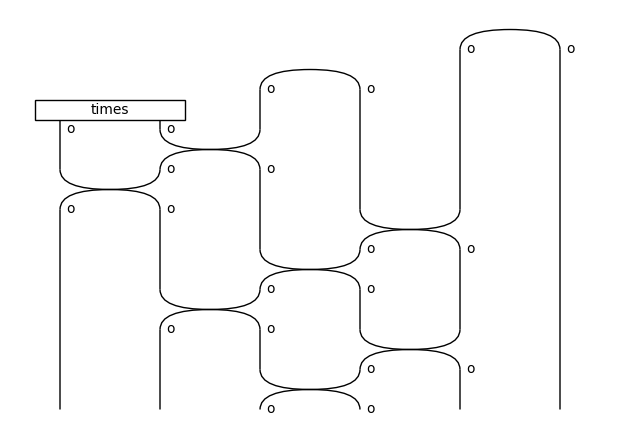

In [4]:
rule = next(r for r in program.rules
            if r.word.name == "times" and r.word.cod == (T >> T) << T)
rule.hypergraph.to_diagram().draw(figsize=(6, 4))

## Parsing: strings to databases, derivations from proofs

A sentence is encoded as a lambda term $\lambda z.\, w_1(\dots w_n(z))$; its image under the same functor is a database of ground facts -- the string positions -- and a query. Proof-relevant semi-naive evaluation (procedure SEMINAIVE-PARSE of Kanazawa 2017) records every ground rule instance, giving a packed forest of derivations.

In [5]:
def encode(sentence):
    def build(z):
        result = z
        for token in reversed(sentence.split()):
            result = constant[token](result)
        return result
    return o(build)

sentence = "two plus three times four"
facts, output = program.database(encode(sentence))
print(sorted((f.pred, f.args) for f in facts))

forest, goal = program.chart(encode(sentence), E)
derivations = list(program.derivations(forest, goal))
for term in derivations:
    tags = [f"{c.name}:{c.cod}" for c in term.constants
            if c.name in OPERATORS]
    print(value(semantics(term)), "<-", ", ".join(tags))

[('four', (4, 5)), ('plus', (1, 2)), ('three', (2, 3)), ('times', (3, 4)), ('two', (0, 1))]
14 <- plus:((t >> e) << t), times:((t >> t) << t)
14 <- plus:((e >> e) << t), times:((t >> t) << t)
20 <- plus:((t >> t) << t), times:((t >> e) << t)


20 <- plus:((t >> e) << t), times:((e >> e) << t)
20 <- plus:((e >> e) << t), times:((e >> e) << t)


Five derivations: two read $2 + (3 \times 4) = 14$ and three read $(2 + 3) \times 4 = 20$. Here is a correct one, drawn as a categorial derivation:

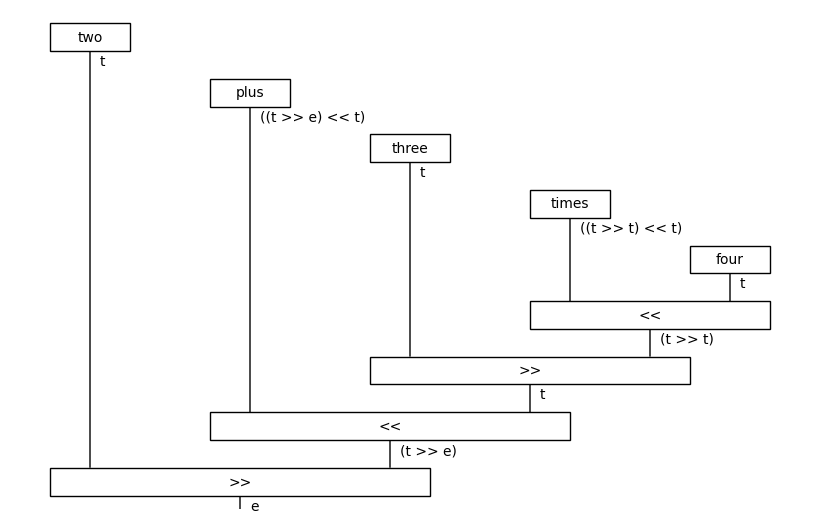

In [6]:
best = next(term for term in derivations
            if value(semantics(term)) == 14)
best.draw(figsize=(8, 5))

## Weighted forests

The packed forest is the provenance polynomial of the query: evaluating it in the counting semiring counts derivations, in the probability semiring it computes the partition function and, via inside-outside message passing on the underlying hypergraph, the marginal of every rule -- which in the `PROB` semiring is the weight times the derivative of the partition function. The parser computes its own gradients.

In [7]:
assert program.inside(
    forest, {r: 1 for r in program.rules}, COUNT)[goal] == 5

uniform = {rule: 1. for rule in program.rules}
partition = program.inside(forest, uniform, PROB)[goal]
marginals = program.marginals(forest, goal, uniform, PROB)
for rule, marginal in sorted(
        marginals.items(), key=lambda pair: -pair[1]):
    if rule.word.name in OPERATORS:
        print(f"{rule.word.name}:{rule.word.cod}",
              round(marginal / partition, 2))

plus:((t >> e) << t) 0.4
plus:((e >> e) << t) 0.4
times:((t >> t) << t) 0.4
times:((e >> e) << t) 0.4
plus:((t >> t) << t) 0.2
times:((t >> e) << t) 0.2


## Learning precedence end-to-end

We train a log-linear supertagger -- one parameter per lexical entry -- through the parser, from pairs of a string and its value. The loss is the negative marginal log-likelihood of the derivations with the correct value, and its gradient is the expected rule count under the full posterior (from `marginals`) minus the expected count under the gold posterior:

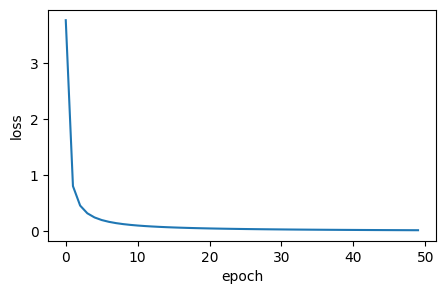

In [8]:
TRAIN = [
    ("two plus three times four", 14), ("two times three plus four", 10),
    ("one plus two times three", 7), ("three times two plus one", 7),
    ("four plus four times two", 12), ("one times two plus three", 5),
    ("two plus two", 4), ("three times three", 9),
    ("one plus one plus one", 3), ("two times two times two", 8),
    ("four", 4)]
TEST = [
    ("four times two plus three", 11), ("one plus four times three", 13),
    ("two times four plus one", 9), ("three plus two times two", 7),
    ("one plus one times four", 5)]

rule_by_word = {rule.word: rule for rule in program.rules}

def analyses(sentence):
    forest, goal = program.chart(encode(sentence), E)
    return forest, goal, [
        (Counter(rule_by_word[c] for c in term.constants),
         value(semantics(term)))
        for term in program.derivations(forest, goal)]

data = [(analyses(sentence), expected) for sentence, expected in TRAIN]
theta = {rule: 0. for rule in program.rules}

def step(learning_rate=.5):
    loss = 0.
    gradient = {rule: 0. for rule in program.rules}
    for (forest, goal, derivations), expected in data:
        weights = {rule: exp(theta[rule]) for rule in program.rules}
        partition = program.inside(forest, weights, PROB)[goal]
        marginals = program.marginals(forest, goal, weights, PROB)
        gold = [(counts, exp(sum(
            n * theta[rule] for rule, n in counts.items())))
            for counts, val in derivations if val == expected]
        gold_mass = sum(score for _, score in gold)
        loss += log(partition) - log(gold_mass)
        for rule in program.rules:
            gradient[rule] += (
                marginals.get(rule, 0.) / partition
                - sum(score * counts.get(rule, 0)
                      for counts, score in gold) / gold_mass)
    for rule in program.rules:
        theta[rule] -= learning_rate * gradient[rule]
    return loss

losses = [step() for _ in range(50)]

from matplotlib import pyplot as plt
plt.figure(figsize=(5, 3))
plt.plot(losses)
plt.xlabel("epoch"), plt.ylabel("loss")
plt.show()

The learnt weights are interpretable: `times` wants the term-level type $(t \mathbin{\backslash} t) / t$ while `plus` avoids it -- the model has discovered that **times binds tighter than plus**, from values alone:

In [9]:
for name in OPERATORS:
    print(name, {key: round(theta[rule_by_word[ty(name)]], 2)
                 for key, ty in OP_TYPES.items()})

for sentence, expected in TEST:
    forest, goal = program.chart(encode(sentence), E)
    score, best = program.viterbi(forest, goal, theta)
    print(f"{sentence} = {value(semantics(best))}"
          f" (expected {expected})")
    assert value(semantics(best)) == expected

plus {'tt': -1.47, 'te': 0.84, 'ee': 0.63}
times {'tt': 3.11, 'te': -0.93, 'ee': -2.17}
four times two plus three = 11 (expected 11)
one plus four times three = 13 (expected 13)


two times four plus one = 9 (expected 9)
three plus two times two = 7 (expected 7)
one plus one times four = 5 (expected 5)


## Where next

The same pipeline scales beyond toy arithmetic by replacing each piece:

* the lexicon by one extracted from **CCGbank** (English), **&AElig;THEL** (Dutch) or the French **TLGbank**, with `Program.from_tagged` consuming the output of a fine-tuned BERT supertagger,
* the log-linear model by the tagger itself, trained end-to-end with the same expected-count gradients (or by calling `Program.inside` on autodifferentiation scalars),
* bounded semi-naive evaluation by its magic-sets rewriting for Earley-style, goal-directed search, and the semiring evaluation by a functor into `discopy.tensor`, where Datalog becomes tensor-network contraction.

See Kanazawa, *Parsing and generation as Datalog query evaluation* (IfCoLog 2017) and `discopy.grammar.datalog`.